# 🌳 ランダムフォレストやってみよう

## このNotebookでやること
スライドの「アイス売上をいろんな条件から予測」を、 **印刷機データ** で体験します。

**ターゲット**: 機体ごとの 月平均印刷枚数（mean_prints）
**入力**: 機種・コントローラ・オプション搭載状況・休止月数 など

## 進め方
1. データを読み込む（17ヶ月分まとめて）
2. 機体ごとの月平均印刷枚数を計算
3. **まず決定木 1 本** で予測してみる（スライド11の図）
4. **次にランダムフォレスト 500 本** で予測（スライド12-13）
5. 1本 vs 500本の精度を比較（スライド14）
6. 特徴量重要度を眺める

迷ったら手を挙げて講師を呼んでください 🙋


---
## 1. 環境セットアップ


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
try:
    import japanize_matplotlib
except ImportError:
    plt.rcParams["font.family"] = ["Yu Gothic", "Meiryo", "MS Gothic", "sans-serif"]

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

DATA_DIR    = Path(r"C:\Users\nakai\Desktop\Claude\FY26_ds\pp_ rawdata_2nd")
META_DIR    = DATA_DIR / "meta"
OPTION_DIR  = DATA_DIR / "option"
MASTER_DIR  = DATA_DIR / "master"

print("META_DIR exists:", META_DIR.exists())


META_DIR exists: True


---
## 2. 月次データを 17ヶ月分まとめて読み込み


In [2]:
def extract_yyyymm(filename: str):
    m = re.search(r"_(\d{6})\.csv$", filename)
    return m.group(1) if m else None

# 月ごとに meta CSV を読み込み、長表に統合
META_COLS = ["mach_id","model_cd","pmtc_counter","create_update_date"]
frames = []
for f in sorted(META_DIR.glob("metadata_*.csv")):
    ym = extract_yyyymm(f.name)
    if ym:
        df = pd.read_csv(f, low_memory=False, usecols=lambda c: c in META_COLS)
        df["yyyymm"] = ym
        frames.append(df)

meta_long = pd.concat(frames, ignore_index=True)
meta_long["yyyymm"] = pd.to_datetime(meta_long["yyyymm"] + "01", format="%Y%m%d")
meta_long["pmtc_counter"] = pd.to_numeric(meta_long["pmtc_counter"], errors="coerce")

print("月次データ shape:", meta_long.shape)
print("ユニーク機体数:", meta_long["mach_id"].nunique())
print("月数:", meta_long["yyyymm"].nunique())
meta_long.head()


月次データ shape: (364250, 5)
ユニーク機体数: 30293
月数: 17


,mach_id,model_cd,pmtc_counter,create_update_date,yyyymm
0,A9CU081000049,C2060,1309883.0,2025-01-26 15:12:15.000,2025-01-01
1,A9CU081000051,C2060,1368931.0,2025-01-22 02:24:54.000,2025-01-01
2,A9CU081000052,C2060,1931540.0,2025-01-21 00:31:35.000,2025-01-01
3,A9CU081000053,C2060,742056.0,2025-01-24 02:24:01.000,2025-01-01
4,A9CU081000054,C2060,674872.0,2025-01-25 01:07:29.000,2025-01-01


---
## 3. 月間印刷枚数を計算（機体別の月次差分）

`pmtc_counter` の月次差分で「その月に何枚印刷したか」を計算します。


In [3]:
meta_long = meta_long.sort_values(["mach_id","yyyymm"]).reset_index(drop=True)
meta_long["prev_counter"] = meta_long.groupby("mach_id")["pmtc_counter"].shift(1)
meta_long["monthly_prints"] = meta_long["pmtc_counter"] - meta_long["prev_counter"]

# 異常値（負・極端な外れ値）は除外
meta_long.loc[meta_long["monthly_prints"] < 0, "monthly_prints"] = np.nan
upper = meta_long["monthly_prints"].quantile(0.995)
meta_long.loc[meta_long["monthly_prints"] > upper, "monthly_prints"] = np.nan

print("計算後の monthly_prints:")
print(meta_long["monthly_prints"].describe().round(0))


計算後の monthly_prints:
count     318061.0
mean       79200.0
std       135294.0
min            0.0
25%         8035.0
50%        28039.0
75%        87305.0
max      1132359.0
Name: monthly_prints, dtype: float64


---
## 4. 機体ごとに「月平均印刷枚数」と「特徴量」を集計

ここで作る:
- `mean_prints` ターゲット（予測したい値）
- `n_active_months` 何ヶ月分のデータがあるか
- `idle_months` 印刷=0だった月数


In [4]:
agg = meta_long.groupby("mach_id").agg(
    model_cd=("model_cd","first"),
    mean_prints=("monthly_prints","mean"),
    n_active_months=("monthly_prints", lambda s: s.notna().sum()),
    idle_months=("monthly_prints", lambda s: (s == 0).sum()),
).reset_index()
print("機体テーブル shape:", agg.shape)
agg.head()


機体テーブル shape: (30293, 5)


,mach_id,model_cd,mean_prints,n_active_months,idle_months
0,A50U001000242,C1070,NaN,0,0
1,A50U001000312,C1070,NaN,0,0
2,A50U001000422,C1070,NaN,0,0
3,A50U001000606,C1070,NaN,0,0
4,A50U001000608,C1070,NaN,0,0


---
## 5. オプション情報を結合（オプション搭載数）

option データから「何個オプションが搭載されているか」を計算して特徴量に加えます。


In [5]:
# 最新月の option ファイルを使う
opt_files = sorted(OPTION_DIR.glob("option_*.csv"))
latest_opt = opt_files[-1]
opt = pd.read_csv(latest_opt, low_memory=False)
print("最新オプションファイル:", latest_opt.name)

opt_cols = [c for c in opt.columns if c.startswith("option_item")]
opt_flag = opt[["mach_id"] + opt_cols].copy()
for c in opt_cols:
    opt_flag[c] = (opt_flag[c].notna() & (opt_flag[c].astype(str) != "None") & (opt_flag[c].astype(str) != "")).astype(int)
opt_flag["option_count"] = opt_flag[opt_cols].sum(axis=1)

agg = agg.merge(opt_flag[["mach_id","option_count"]], on="mach_id", how="left")
agg["option_count"] = agg["option_count"].fillna(0).astype(int)
print(agg["option_count"].describe().round(1))


最新オプションファイル: option_20260601_113832_202605.csv
count    30293.0
mean         4.1
std          3.1
min          0.0
25%          2.0
50%          4.0
75%          6.0
max         19.0
Name: option_count, dtype: float64


---
## 6. 機種マスタを結合（製品名・コントローラ）


In [6]:
m_product = pd.read_csv(MASTER_DIR / "product.csv", encoding="utf-8-sig")
agg["mach_prefix"] = agg["mach_id"].str[:4]
agg = agg.merge(
    m_product[["product","product_name","controller"]].rename(columns={"product":"mach_prefix"}),
    on="mach_prefix", how="left"
)
print("結合後:", agg.shape)
agg.head()


結合後: (30293, 9)


,mach_id,model_cd,mean_prints,n_active_months,idle_months,option_count,mach_prefix,product_name,controller
0,A50U001000242,C1070,NaN,0,0,0,A50U,NaN,NaN
1,A50U001000312,C1070,NaN,0,0,4,A50U,NaN,NaN
2,A50U001000422,C1070,NaN,0,0,0,A50U,NaN,NaN
3,A50U001000606,C1070,NaN,0,0,0,A50U,NaN,NaN
4,A50U001000608,C1070,NaN,0,0,2,A50U,NaN,NaN


---
## 7. 学習用データを準備

- ターゲット `y` = `mean_prints`
- 特徴量 `X` = 機種・コントローラ・オプション数・休止月数・有効月数


In [7]:
# 学習に使えるデータだけ残す
ml = agg[agg["mean_prints"].notna() & (agg["n_active_months"] >= 3)].copy()
print(f"学習対象機体: {len(ml):,}台")

y = ml["mean_prints"]
X = ml[["option_count","idle_months","n_active_months","model_cd","product_name","controller"]]

# カテゴリ列をワンホット（model_cd, product_name, controller を数値化）
X = pd.get_dummies(X, columns=["model_cd","product_name","controller"], dummy_na=True)
X = X.astype({c: int for c in X.select_dtypes(include="bool").columns})
print(f"特徴量の数: {X.shape[1]}")


学習対象機体: 24,939台
特徴量の数: 68


---
## 8. 訓練データとテストデータに分ける

80% で学習、20% で評価。


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"訓練: {len(X_train):,}台")
print(f"テスト: {len(X_test):,}台")


訓練: 19,951台
テスト: 4,988台


---
## 9. 🌳 まず「決定木 1 本」で予測してみる（スライド11）

スライド11の図：
> 気温 30℃以上？ → YES → イベントあり？ → … → 200本

これと同じことを、印刷機データで実演します。「1本の木だけだとちょっと頼りない」というのを実感するための比較対象です。


In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

tree = DecisionTreeRegressor(max_depth=10, random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

mae_tree = mean_absolute_error(y_test, pred_tree)
r2_tree  = r2_score(y_test, pred_tree)
print(f"🌳 決定木 1 本:")
print(f"  MAE = {mae_tree:,.0f} 枚/月")
print(f"  R²  = {r2_tree:.3f}")


🌳 決定木 1 本:
  MAE = 56,800 枚/月
  R²  = 0.289


---
## 10. 🌲🌲🌲 ランダムフォレスト = 木 500 本！（スライド12-13）

スライド12-13の図：
> 木① 木② 木③ … 木500 → 予測値を全部平均 → 答え

500本の決定木を作って、それぞれの予測の平均を最終予測にします。


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,    # 500本の木
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
r2_rf  = r2_score(y_test, pred_rf)
print(f"🌲🌲🌲 ランダムフォレスト 500 本:")
print(f"  MAE = {mae_rf:,.0f} 枚/月")
print(f"  R²  = {r2_rf:.3f}")


🌲🌲🌲 ランダムフォレスト 500 本:
  MAE = 55,355 枚/月
  R²  = 0.328


---
## 11. 1本 vs 500本の比較（スライド14：なぜ精度が上がるの？）


In [11]:
print("=== 決定木 1 本 vs ランダムフォレスト 500 本 ===")
print(f"  決定木 1 本           : MAE = {mae_tree:,.0f}, R² = {r2_tree:.3f}")
print(f"  ランダムフォレスト 500 本: MAE = {mae_rf:,.0f}, R² = {r2_rf:.3f}")
print(f"  → MAE が {(mae_tree - mae_rf)/mae_tree*100:+.1f}% 改善")


=== 決定木 1 本 vs ランダムフォレスト 500 本 ===
  決定木 1 本           : MAE = 56,800, R² = 0.289
  ランダムフォレスト 500 本: MAE = 55,355, R² = 0.328
  → MAE が +2.5% 改善


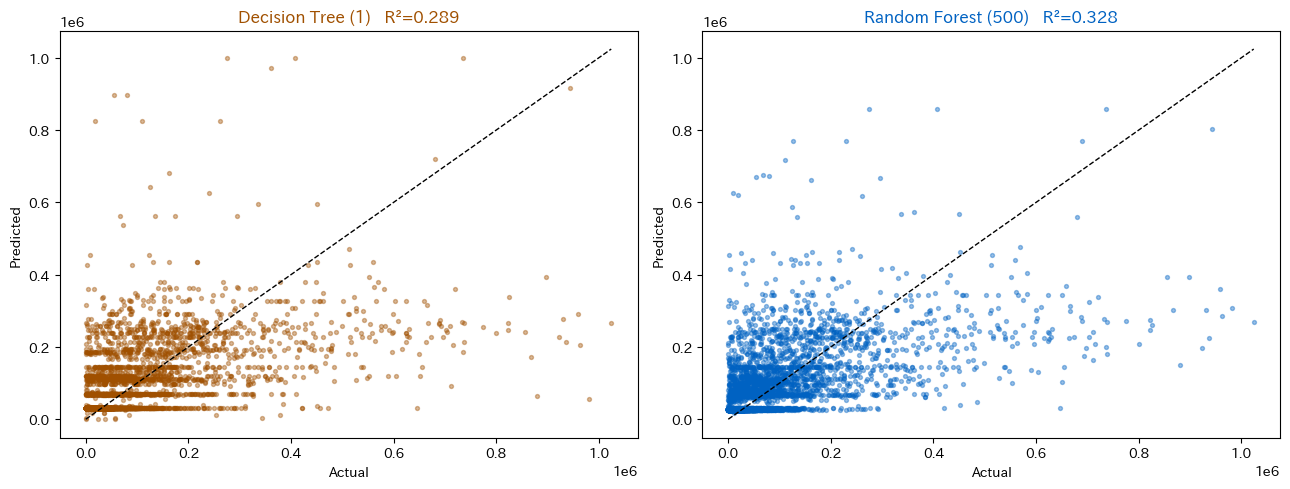

In [12]:
# 予測 vs 実測の散布図を 2 枚並べて比較
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, pred_tree, s=8, alpha=0.4, color="#A05000")
lim = max(y_test.max(), pred_tree.max())
axes[0].plot([0, lim], [0, lim], "k--", linewidth=1)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Decision Tree (1)   R²={r2_tree:.3f}", color="#A05000", fontweight="bold")

axes[1].scatter(y_test, pred_rf, s=8, alpha=0.4, color="#0062C2")
lim = max(y_test.max(), pred_rf.max())
axes[1].plot([0, lim], [0, lim], "k--", linewidth=1)
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Random Forest (500)   R²={r2_rf:.3f}", color="#0062C2", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 12. 何が予測に効いている？（特徴量重要度）

500本の木が「どの特徴量をどれだけ参考にしているか」のランキング。


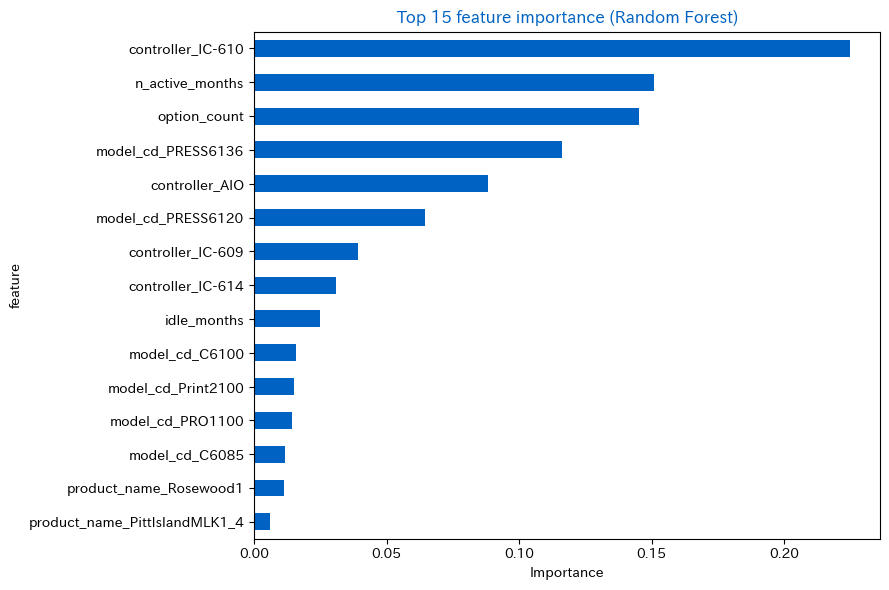

                      feature  importance
            controller_IC-610    0.224903
              n_active_months    0.150824
                 option_count    0.145107
           model_cd_PRESS6136    0.116287
               controller_AIO    0.088342
           model_cd_PRESS6120    0.064531
            controller_IC-609    0.039117
            controller_IC-614    0.030829
                  idle_months    0.024789
               model_cd_C6100    0.015832
           model_cd_Print2100    0.015114
             model_cd_PRO1100    0.014286
               model_cd_C6085    0.011603
       product_name_Rosewood1    0.011326
product_name_PittIslandMLK1_4    0.005855


In [13]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
importances.head(15).plot.barh(x="feature", y="importance", ax=ax, color="#0062C2", legend=False)
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Top 15 feature importance (Random Forest)", color="#0062C2", fontweight="bold")
plt.tight_layout()
plt.show()

print(importances.head(15).to_string(index=False))


---
## 13. 振り返り

このNotebookでやったこと:

| ステップ | スライド | コード |
|---|---|---|
| 決定木 1 本で予測 | スライド11 | `DecisionTreeRegressor` |
| 木を 500 本に増やしたランダムフォレスト | スライド12-13 | `RandomForestRegressor(n_estimators=500)` |
| 1本 vs 500本の精度比較 | スライド14 | MAE と R² を並べて表示 |
| どの特徴量が効いてる？ | スライド15-19 | `feature_importances_` |

### 大事なメッセージ
- **1本の木はバラついた答えを出すが、500本平均すると安定する**（スライド15のたとえ）
- 「ブラックボックス」と言われるが、**重要度ランキングで「何が効いてるか」は見える**（スライド16-17）

次は「重回帰分析やってみよう」 に進みます 🚶
